# TP-LoRA on citrus fruit defect segmentation — minimal runnable example

**Paper:** Yun Zhu, Xiongjiang Cai, Shuwen Liu, Zhiyue Yu, Lianfeng Gao, Youyun Xu,
*"Parameter-Efficient Fine-Tuning for citrus fruit defect segmentation model based on text prompt"*,
Engineering Applications of Artificial Intelligence 160 (2025) 111765.
[DOI 10.1016/j.engappai.2025.111765](https://doi.org/10.1016/j.engappai.2025.111765)

**Official code (MIT):** [`caixiongjiang/TP-LoRA`](https://github.com/caixiongjiang/TP-LoRA) pinned at commit `daa49a5c01d7ff46655028d0802160c35fd71c78` (default `main`, 2025-08-12; the repo is the authors' own, asserted by the Crossref *is-supplemented-by* relation of the DOI).

## What this notebook does (exact scope)

This notebook reproduces **two small, runnable analyses** from the pinned author code and released assets, entirely on Colab:

1. **Pretrained base-model inference.** Load the authors' released trained segmentation checkpoint `Swin-T-Att-UNet-Orange-Navel-4.5k.pth` (README-reported mIoU 89.75% on Orange-Navel-4.5k) into the pinned `swinTS_Att_Unet` class and run the author's predict/`get_miou_png` logic on a few images from the released `Orange-Navel-1.5k` dataset, then compute mIoU on that small subset with the authors' `compute_mIoU`.
2. **TP-LoRA model construction + tuned-parameter count.** Build the pinned `TP_LoRA` model under the author's published-table configuration (`summary.py`, Swin-Tiny section: LARGE text prompt, `mlp_dim=0.25`, `lora_dim=8`, `act='ReLU'`, `in_location='ATT+MLP'`, `out_location='DEEP'`) and count its trainable parameters with the author's `calculate_unfrozen_parameter_ratio()`, comparing with the README table (TP-LoRA / Swin-Tiny: 0.32 M tuned parameters); the README PEFT usage-example configuration (`in_location='ATT'`) is counted as a second documented variant.

## What this notebook deliberately does NOT do

- **No fine-tuned TP-LoRA inference and no training.** No trained TP-LoRA checkpoint was released (the README's `logs/.../TP-LoRA/best.pth` path is not published); re-running the PEFT stage would need ~500-epoch GPU training. The TP-LoRA model is built from the pinned code and its *untrained* adapters are only used for the parameter-count check, never for prediction.
- No Orange-Navel-5.3k experiments (dataset withheld by the authors for commercial reasons), no LayerCAM visualization, no PEFT baseline comparison, no benchmark reproduction.
- The subset mIoU is a **plausibility check on a handful of images**, not a verification of the paper-level 89.75% figure (see the caveat in the mIoU section).

> **AI-assisted adaptation notice / AI支援による改変について:** The authors did not provide this Colab notebook. We use the authors' pinned source files unmodified except for three minimal, documented compatibility patches (hardcoded home-directory paths, `np.int` removal, hardcoded `.to('cuda')` device placement). The executed example and checks below were validated on Colab, but untested behaviour of the adapted code is not guaranteed.
>
> **日本語:** 論文「テキストプロンプトに基づく柑橘類果実欠陥セグメンテーションのパラメータ効率化ファインチューニング（TP-LoRA）」の最小実行例です。著者公開のチェックポイントを用いた推論と、小規模サブセットでの mIoU 評価、TP-LoRA モデル構築と調整パラメータ数の確認を行います。TP-LoRA の学習済み PEFT 重みは公開されていないため、ファインチューニング済みモデルの推論・学習は行いません。

## Runtime selection / 実行環境の選択

**CPU is sufficient for this notebook** (Runtime → Change runtime type → **CPU**). The Swin-Tiny Att-UNet forward pass on single 224×224 images takes only seconds on CPU, and the TP-LoRA parameter count needs no GPU at all. The notebook auto-detects a GPU and uses it if one is present (the author code does the same), but no GPU is required.

**Expected cost:** downloads ≈ 0.52 GB (326 MB dataset zip + 183 MB checkpoint + 9 MB prompt vectors + small code files), and roughly 10–20 minutes end-to-end on a free CPU runtime (estimates; measured times appear in the outputs).

**日本語:** このノートブックは CPU で十分動作します（ランタイム → ランタイムのタイプを変更 → CPU）。GPU が割り当てられた場合は自動的に使います。ダウンロードは合計約 0.52 GB、所要時間の目安は 10〜20 分です。

In [ ]:
import sys, platform, torch

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU runtime")

Python: 3.13.16
PyTorch: 2.11.0+cpu
Device: cpu | CPU runtime


## Dependencies / 依存ライブラリ

The authors' `requirements.txt` pins an old stack (torch 1.10, numpy 1.21, 2021-era). Downgrading Colab's preinstalled PyTorch would be slow and unnecessary: every package the demonstration path needs — `torch`, `numpy`, `Pillow`, `opencv-python` (cv2), `scipy` (TP-LoRA adapter construction), `PyYAML`, `matplotlib`, `pandas`, `tqdm` — is already preinstalled on current Colab runtimes. The cell below **verifies** this instead of reinstalling anything; if a check fails, the notebook fails loudly rather than silently substituting a different algorithm.

**日本語:** 著者の requirements.txt は古いバージョン固定ですが、Colab にプレインストールされた最新スタックをそのまま使い、ダウングレードは行いません。必要なパッケージの存在を確認します。

In [ ]:
import importlib

for pkg in ["numpy", "PIL", "cv2", "scipy", "yaml", "matplotlib", "pandas", "tqdm"]:
    m = importlib.import_module(pkg)
    print(f"{pkg:12s} OK  {getattr(m, '__version__', '')}")

numpy        OK  2.1.3
PIL          OK  11.3.0
cv2          OK  5.0.0
scipy        OK  1.16.3
yaml         OK  6.0.3
matplotlib   OK  3.10.0


pandas       OK  2.2.3
tqdm         OK  4.67.3


## Step 1 — Acquire the pinned author code / 著者コードの取得

We fetch the author repository at the exact pinned commit `daa49a5c01d7ff46655028d0802160c35fd71c78` with a **partial, blobless clone plus sparse checkout** (only `nets/` and `utils/` are materialized; all repository bytes stay under `/content` on this Colab VM). The checkout is asserted against the pinned commit, so the code provenance is exact.

**日本語:** 著者リポジトリを固定コミット `daa49a5c01d7ff46655028d0802160c35fd71c78` で部分クローン（sparse checkout）し、コミット一致を検証します。すべてのリポジトリデータは Colab VM 上の `/content` に置かれます。

In [ ]:
import os, subprocess

PIN = "daa49a5c01d7ff46655028d0802160c35fd71c78"
REPO_URL = "https://github.com/caixiongjiang/TP-LoRA.git"
REPO_DIR = "/content/TP-LoRA"

if not os.path.isdir(os.path.join(REPO_DIR, ".git")):
    subprocess.run(["git", "clone", "--filter=blob:none", "--no-checkout", "--depth", "1",
                    REPO_URL, REPO_DIR], check=True)

def git(*args):
    return subprocess.run(["git", "-C", REPO_DIR, *args], check=True,
                          capture_output=True, text=True).stdout.strip()

# Pin the exact commit; fall back to an explicit SHA fetch if the shallow tip differs.
if git("rev-parse", "HEAD") != PIN:
    subprocess.run(["git", "-C", REPO_DIR, "fetch", "--depth", "1", "origin", PIN], check=True)
subprocess.run(["git", "-C", REPO_DIR, "checkout", "--detach", PIN], check=True)
subprocess.run(["git", "-C", REPO_DIR, "sparse-checkout", "set", "--cone", "nets", "utils"], check=True)
subprocess.run(["git", "-C", REPO_DIR, "checkout"], check=True)

head = git("rev-parse", "HEAD")
assert head == PIN, f"checkout mismatch: {head} != {PIN}"
print("Checked out pinned commit:", head)
print("Key files present:", os.path.isfile(os.path.join(REPO_DIR, "nets/BaseModel/swinTS_Att_Unet.py")),
      os.path.isfile(os.path.join(REPO_DIR, "nets/TP_LoRA/prompt_vector.json")))

Checked out pinned commit: daa49a5c01d7ff46655028d0802160c35fd71c78
Key files present: True True


## Step 2 — Three minimal compatibility patches / 最小限の互換性パッチ

The pinned code needs three tiny fixes to run in Colab. None of them changes any scientific operation:

| # | Author code (pinned file) | Problem | Patch |
|---|---|---|---|
| 1 | `nets/TP_LoRA/utils.py` — `read_config`, `read_vector_from_json`, `Update_TP_LoRA_Set` | absolute paths hardcoded to the author's machine (`/home/caixj/...`) | rewrite defaults to the Colab checkout `/content/TP-LoRA/...` |
| 2 | `utils/utils_metrics.py` — `compute_mIoU` | `np.array(hist, np.int)`; `np.int` was removed in NumPy ≥ 1.24 | `np.int` → `int` (same dtype semantics) |
| 3 | `nets/TP_LoRA/tp_lora_adapter.py` — `TP_LoRA_Adapter.forward`, `TP_LoRA_Adapter_CNN.forward` | text vectors hardcoded `.to('cuda')` → crashes on CPU runtimes | `.to('cuda')` → `.to(x.device)` (device-aware placement; identical math) |

**日本語:** 著者コードの絶対パス、削除された `np.int`、CPU で壊れる `.to('cuda')` の3点のみ修正します。科学計算そのものは変更しません。

In [ ]:
from pathlib import Path

# Patch 1: author-home paths -> Colab checkout paths
tp_utils = Path(REPO_DIR) / "nets/TP_LoRA/utils.py"
s = tp_utils.read_text()
n1 = s.count("/home/caixj/PycharmProjects/TP-LoRA/nets/TP_LoRA/")
s = s.replace("/home/caixj/PycharmProjects/TP-LoRA/nets/TP_LoRA/config.yaml",
              f"{REPO_DIR}/nets/TP_LoRA/config.yaml")
s = s.replace("/home/caixj/PycharmProjects/TP-LoRA/nets/TP_LoRA/prompt_vector.json",
              f"{REPO_DIR}/nets/TP_LoRA/prompt_vector.json")
tp_utils.write_text(s)

# Patch 2: np.int removal in compute_mIoU
metrics = Path(REPO_DIR) / "utils/utils_metrics.py"
m = metrics.read_text()
n2 = m.count("np.array(hist, np.int)")
m = m.replace("np.array(hist, np.int)", "np.array(hist, int)")
metrics.write_text(m)

# Patch 3: device-aware text-vector placement in the TP-LoRA adapters
adapter = Path(REPO_DIR) / "nets/TP_LoRA/tp_lora_adapter.py"
a = adapter.read_text()
n3 = a.count(".to('cuda')")
a = a.replace(".to('cuda')", ".to(x.device)")
adapter.write_text(a)

print(f"patched path defaults: {n1} occurrences | np.int fixes: {n2} | .to('cuda') fixes: {n3}")
assert n1 >= 3 and n2 == 1 and n3 == 4, "unexpected patch counts - inspect the pinned sources" 

patched path defaults: 3 occurrences | np.int fixes: 1 | .to('cuda') fixes: 4


## Step 3 — Download the released checkpoint and dataset / 重みとデータセットの取得

From the authors' GitHub release `v1.0.0` (sizes from the release-asset metadata; no official checksums are published, so we verify byte counts and parse-ability after download):

- `Swin-T-Att-UNet-Orange-Navel-4.5k.pth` — 183,529,613 bytes; the trained basic segmentation network (Swin-T-Att-UNet, `num_classes = 3 + 1` per the README's pretrain configuration for Orange-Navel-4.5k).
- `Orange-Navel-1.5k.zip` — 326,417,350 bytes; the released original portion (1448 images) of the Orange-Navel-4.5k pretraining dataset (512×512 JPEG images + VOC PNG masks).

The 9 MB `nets/TP_LoRA/prompt_vector.json` (BERT text-prompt vectors pre-computed by the authors with `bert-base`) already came with the sparse checkout of `nets/`.

**日本語:** 著者リリース v1.0.0 から学習済み基本モデルのチェックポイントと Orange-Navel-1.5k データセットをダウンロードし、バイト数を検証します。

In [ ]:
import urllib.request

CKPT_URL = "https://github.com/caixiongjiang/TP-LoRA/releases/download/v1.0.0/Swin-T-Att-UNet-Orange-Navel-4.5k.pth"
CKPT_SIZE = 183529613
DATA_URL = "https://github.com/caixiongjiang/TP-LoRA/releases/download/v1.0.0/Orange-Navel-1.5k.zip"
DATA_SIZE = 326417350

def fetch(url, dest, expected_size):
    if os.path.exists(dest) and os.path.getsize(dest) == expected_size:
        print("already present:", dest); return
    print("downloading", url)
    urllib.request.urlretrieve(url, dest)
    got = os.path.getsize(dest)
    assert got == expected_size, f"size mismatch for {dest}: {got} != {expected_size}"
    print(f"OK {dest}: {got:,} bytes")

fetch(CKPT_URL, "/content/Swin-T-Att-UNet-Orange-Navel-4.5k.pth", CKPT_SIZE)
fetch(DATA_URL, "/content/Orange-Navel-1.5k.zip", DATA_SIZE)

downloading https://github.com/caixiongjiang/TP-LoRA/releases/download/v1.0.0/Swin-T-Att-UNet-Orange-Navel-4.5k.pth


OK /content/Swin-T-Att-UNet-Orange-Navel-4.5k.pth: 183,529,613 bytes
downloading https://github.com/caixiongjiang/TP-LoRA/releases/download/v1.0.0/Orange-Navel-1.5k.zip


OK /content/Orange-Navel-1.5k.zip: 326,417,350 bytes


## Step 4 — Inspect the dataset archive and extract a small sample / データセットの中身を確認

The paper/repo document Orange-Navel as a VOC-style set (`VOC2007/JPEGImages`, `VOC2007/SegmentationClass`, `VOC2007/ImageSets/Segmentation`). The cell below prints the archive layout **actually found**, checks for author-provided split files, and extracts only a handful of image/mask pairs (a deterministic subset) — never the full 1448-image set into memory at once.

**日本語:** アーカイブの実際の構成を確認し、検証用の少数ペアのみ抽出します。

In [ ]:
import zipfile, collections

ZIP_PATH = "/content/Orange-Navel-1.5k.zip"
zf = zipfile.ZipFile(ZIP_PATH)
names = zf.namelist()

# summarize the real layout instead of assuming it
ext_counts = collections.Counter(os.path.splitext(n)[1].lower() for n in names if not n.endswith("/"))
print("entries:", len(names), "| by extension:", dict(ext_counts))
top = collections.Counter(n.split("/")[0] for n in names)
print("top-level:", dict(top))
splits = sorted(n for n in names if "ImageSets" in n and n.endswith(".txt"))
print("split files:", splits)
jpegs = sorted(n for n in names if n.lower().endswith(".jpg"))
pngs = sorted(n for n in names if n.lower().endswith(".png"))
print("jpg:", len(jpegs), "png:", len(pngs))
print("example jpg:", jpegs[0], "| example png:", pngs[0] if pngs else None)

entries: 2906 | by extension: {'.md': 1, '.txt': 4, '.jpg': 1448, '.png': 1448}
top-level: {'VOC2007': 2906}
split files: ['VOC2007/ImageSets/Segmentation/test.txt', 'VOC2007/ImageSets/Segmentation/train.txt', 'VOC2007/ImageSets/Segmentation/trainval.txt', 'VOC2007/ImageSets/Segmentation/val.txt']
jpg: 1448 png: 1448
example jpg: VOC2007/JPEGImages/img1.jpg | example png: VOC2007/SegmentationClass/img1.png


## Step 5 — Sample selection and input preview / サンプル選択と入力プレビュー

We pick **8 image/mask pairs**: from the authors' own `test.txt` (or `val.txt`) split file when the archive contains one, otherwise a fixed-stride subset of the sorted JPEG names (deterministic; recorded here). The preview below shows the real input photograph and its ground-truth annotation mask as delivered by the authors — this is author data, not a model output.

**日本語:** アーカイブ内の分割ファイル（無ければソート名から固定間隔）から 8 ペアを決定論的に選び、入力画像と正解アノテーションを表示します。

In [ ]:
import numpy as np
from PIL import Image

N_SAMPLES = 8
EXTRACT_DIR = "/content/sample"

id_from = lambda p: os.path.splitext(os.path.basename(p))[0]
split_ids = []
for sp in [s for s in splits if s.endswith(("test.txt", "val.txt"))]:
    lines = [id_from(l) for l in zf.read(sp).decode().splitlines() if id_from(l)]
    if lines:
        split_ids = lines
        print("using author split:", sp, "|", len(lines), "ids")
        break

if split_ids:
    step = max(1, len(split_ids) // N_SAMPLES)
    chosen = sorted(split_ids[::step])[:N_SAMPLES]
else:
    jid = sorted(id_from(j) for j in jpegs)
    step = max(1, len(jid) // N_SAMPLES)
    chosen = sorted(jid[::step])[:N_SAMPLES]
print("chosen sample ids:", chosen)

jpg_prefix = next(p for p in ("VOC2007/JPEGImages/", "JPEGImages/") if any(j.startswith(p) for j in jpegs))
png_prefix = next(p for p in ("VOC2007/SegmentationClass/", "SegmentationClass/") if any(q.startswith(p) for q in pngs))

os.makedirs(EXTRACT_DIR, exist_ok=True)
for sid in chosen:
    for member, dest in [(jpg_prefix + sid + ".jpg", f"{EXTRACT_DIR}/{sid}.jpg"),
                         (png_prefix + sid + ".png", f"{EXTRACT_DIR}/{sid}.png")]:
        with zf.open(member) as src, open(dest, "wb") as out:
            out.write(src.read())
print("extracted", len(chosen), "pairs to", EXTRACT_DIR)
print("image size example:", Image.open(f"{EXTRACT_DIR}/{chosen[0]}.jpg").size,
      "| mask classes present:", np.unique(np.array(Image.open(f"{EXTRACT_DIR}/{chosen[0]}.png")))[:10])

using author split: VOC2007/ImageSets/Segmentation/test.txt | 290 ids
chosen sample ids: ['img1002', 'img1176', 'img1313', 'img156', 'img300', 'img477', 'img65', 'img826']
extracted 8 pairs to /content/sample
image size example: (512, 512) | mask classes present: [0 3]


The left panel is the original 512×512 photograph from the released Orange-Navel dataset; the right panel overlays the authors' ground-truth mask (class indices → colours, background black). Class names for the Orange-Navel-4.5k label set come from the author code (`predict.py` / `get_miou.py` comments): *background, sunburn, ulcer, wind scarring*.

**日本語:** 左が元画像、右が著者提供の正解マスクのオーバーレイです。クラス名は著者コードのコメントに基づきます。

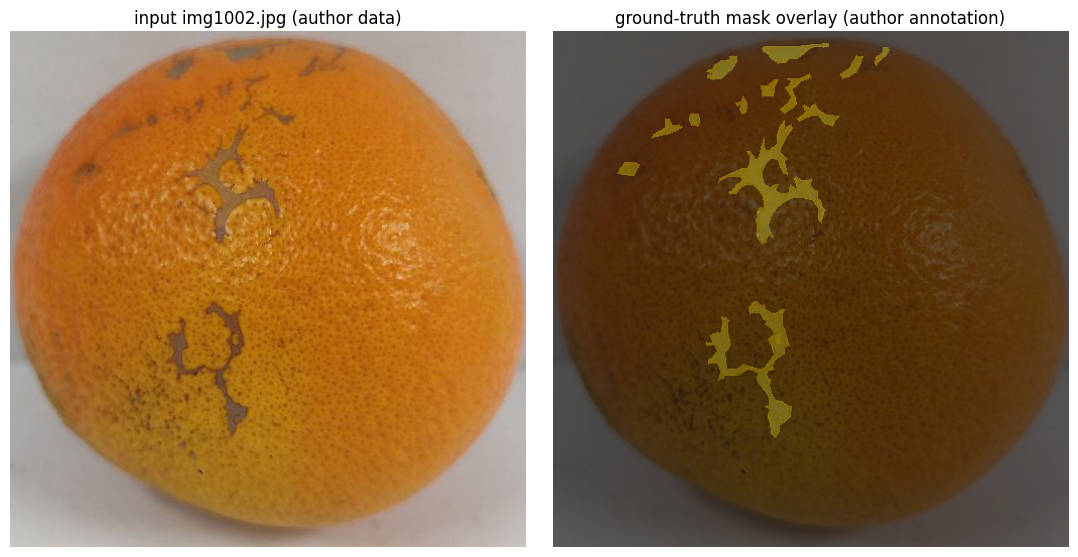

In [ ]:
import matplotlib.pyplot as plt

name_classes = ["background", "sunburn", "ulcer", "wind scarring"]
gt_colors = np.array([(0, 0, 0), (128, 0, 0), (0, 128, 0), (128, 128, 0)], np.uint8)  # author unet.py colors, 4.5k set

sid = chosen[0]
img = Image.open(f"{EXTRACT_DIR}/{sid}.jpg").convert("RGB")
gt = np.array(Image.open(f"{EXTRACT_DIR}/{sid}.png"))
overlay = gt_colors[gt]

fig, ax = plt.subplots(1, 2, figsize=(11, 5.5))
ax[0].imshow(img); ax[0].set_title(f"input {sid}.jpg (author data)"); ax[0].axis("off")
ax[1].imshow(img); ax[1].imshow(overlay, alpha=0.55)
ax[1].set_title("ground-truth mask overlay (author annotation)"); ax[1].axis("off")
plt.tight_layout(); plt.show()

## Step 6 — Load the released base checkpoint / 学習済みチェックポイントの読み込み

We build the pinned `swinTS_Att_Unet` with `num_classes = 3 + 1 = 4` (the README's Orange-Navel-4.5k pretrain configuration) and load the released state dict, reporting missing/unexpected keys. The author's own PEFT loader loads this file directly (`train.py`, "Use BaseModel train PEFT methods"), i.e. it is a raw state dict; we still report a key inventory instead of assuming it.

**日本語:** 著者コードの `swinTS_Att_Unet`（num_classes=4）を構築し、リリースされた state dict を読み込み、キーの欠落・過剰を報告します。

In [ ]:
import torch
sys.path.insert(0, REPO_DIR)
os.chdir(REPO_DIR)

from nets.BaseModel.swinTS_Att_Unet import swinTS_Att_Unet

NUM_CLASSES = 3 + 1  # Orange-Navel-4.5k: background, sunburn, ulcer, wind scarring (train.py / README)

net = swinTS_Att_Unet(num_classes=NUM_CLASSES, pretrained=False, backbone="swin_T_224")
ckpt = torch.load("/content/Swin-T-Att-UNet-Orange-Navel-4.5k.pth", map_location="cpu")
if isinstance(ckpt, dict) and "model" in ckpt and not any(
        k.startswith(("swin_backbone", "final_conv")) for k in ckpt if isinstance(k, str)):
    ckpt = ckpt["model"]  # author backbone-init archives wrap weights under "model"; not expected here
ckpt = { (k[7:] if k.startswith("module.") else k): v for k, v in ckpt.items() }
report = net.load_state_dict(ckpt, strict=False)
print("missing keys:", len(report.missing_keys), "| unexpected keys:", len(report.unexpected_keys))
print("checkpoint tensors:", len(ckpt), "| model parameters: %.2fM" % (sum(p.numel() for p in net.parameters()) / 1e6))
assert len(report.unexpected_keys) == 0, f"unexpected checkpoint keys: {report.unexpected_keys[:5]}"
assert not any(k.startswith("swin_backbone") for k in report.missing_keys), "backbone weights did not load"
net = net.eval().to(device)
print("base Swin-T-Att-UNet ready on", device)

/usr/local/lib/python3.13/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


missing keys: 0 | unexpected keys: 0
checkpoint tensors: 410 | model parameters: 45.78M
base Swin-T-Att-UNet ready on cpu


## Step 7 — Inference with the author's predict logic / 著者の推論処理

This is the author's `Unet.detect_image` / `get_miou_png` logic from `unet.py`, verbatim in its numerical steps: letterbox-resize to 224×224 (`utils.utils.resize_image`), `preprocess_input` (÷255), HWC→CHW, forward, softmax, crop back, resize to original size, `argmax`. The prediction is rendered with the author's colour table for this dataset (`unet.py`, 4.5k colour block) and blended at the author's `mix_type=0` alpha of 0.7.

**日本語:** 著者 `unet.py` の `detect_image`/`get_miou_png` と同じ数値処理（レターボックス 224×224、÷255、softmax、argmax）で推論し、著者のカラーテーブルで重ね描きします。

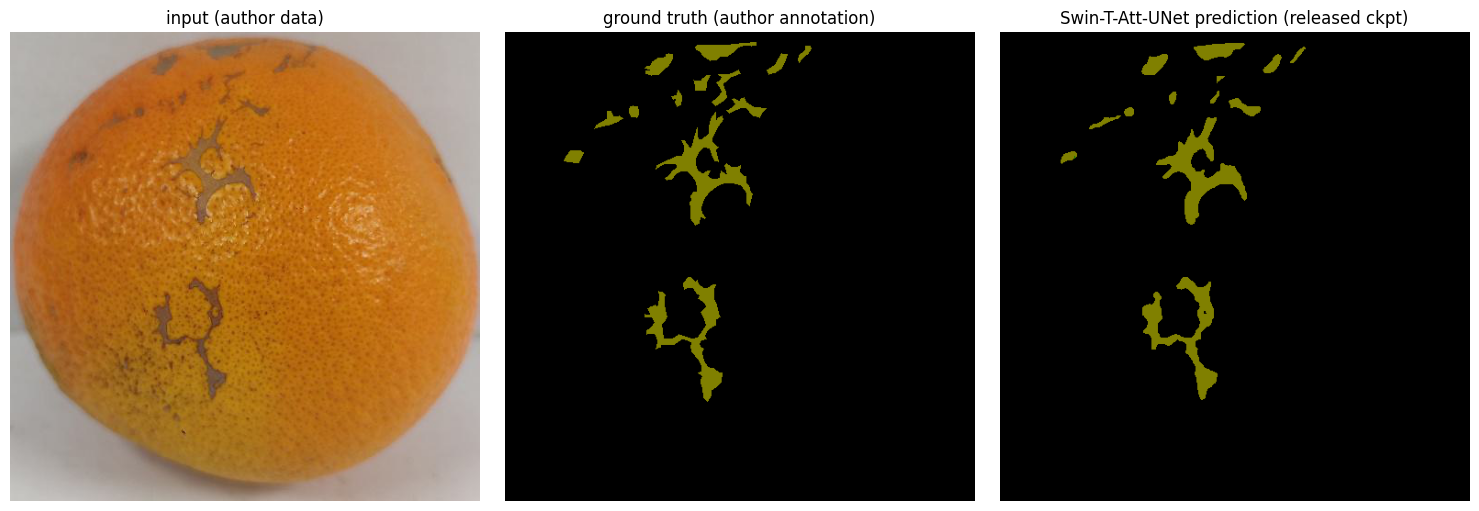

per-class pixel counts (prediction): {'background': np.int64(253732), 'sunburn': np.int64(0), 'ulcer': np.int64(3), 'wind scarring': np.int64(8409)}


In [ ]:
import torch.nn.functional as F
import cv2
from utils.utils import cvtColor, preprocess_input, resize_image

INPUT_SHAPE = [224, 224]  # author default (unet.py _defaults)

@torch.no_grad()
def get_miou_png(image):
    # exact numerical path of the author's Unet.get_miou_png (unet.py:204-223)
    image = cvtColor(image)
    original_h, original_w = np.array(image).shape[:2]
    image_data, nw, nh = resize_image(image, (INPUT_SHAPE[1], INPUT_SHAPE[0]))
    image_data = np.expand_dims(np.transpose(preprocess_input(np.array(image_data, np.float32)), (2, 0, 1)), 0)
    images = torch.from_numpy(image_data).to(device)
    pr = net(images)[0]
    pr = F.softmax(pr.permute(1, 2, 0), dim=-1).cpu().numpy()
    pr = pr[int((INPUT_SHAPE[0] - nh) // 2): int((INPUT_SHAPE[0] - nh) // 2 + nh),
            int((INPUT_SHAPE[1] - nw) // 2): int((INPUT_SHAPE[1] - nw) // 2 + nw)]
    pr = cv2.resize(pr, (original_w, original_h), interpolation=cv2.INTER_LINEAR)
    return pr.argmax(axis=-1)

sid = chosen[0]
pred = get_miou_png(Image.open(f"{EXTRACT_DIR}/{sid}.jpg"))
gt = np.array(Image.open(f"{EXTRACT_DIR}/{sid}.png"))
seg_img = gt_colors[pred]

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(Image.open(f"{EXTRACT_DIR}/{sid}.jpg").convert("RGB")); ax[0].set_title("input (author data)"); ax[0].axis("off")
ax[1].imshow(gt_colors[gt]); ax[1].set_title("ground truth (author annotation)"); ax[1].axis("off")
ax[2].imshow(seg_img); ax[2].set_title("Swin-T-Att-UNet prediction (released ckpt)"); ax[2].axis("off")
plt.tight_layout(); plt.show()

print("per-class pixel counts (prediction):", dict(zip(name_classes, np.bincount(pred.ravel(), minlength=NUM_CLASSES))))

## Step 8 — mIoU on the small sample / 小規模サブセットの mIoU

We run the authors' `compute_mIoU` (`utils/utils_metrics.py`, patched `np.int`) over the **8 selected pairs only** and save the predictions in the author's `miou_out/detection-results` layout.

> **Caveat (important):** the released Orange-Navel-1.5k archive is the original portion of the **pretraining** set Orange-Navel-4.5k. If the archive ships the authors' train/val/test split we honour it; if a picked image belongs to the training split, the score is optimistically biased. Either way this 8-image mIoU is a **plausibility check** that the checkpoint and pipeline behave as documented — it is not the paper-level 89.75% test-set result, which used the full dataset and protocol we cannot rerun here.

**日本語:** 著者の `compute_mIoU` を 8 ペアのみに適用します。Orange-Navel-1.5k は事前学習データの一部のため、学習画像が含まれる可能性があり、この値は論文値（89.75%）の検証ではなく、パイプラインの動作確認です。

In [ ]:
from utils.utils_metrics import compute_mIoU

PRED_DIR = "/content/miou_out/detection-results"
GT_DIR = f"{EXTRACT_DIR}"  # extracted author SegmentationClass PNGs live here
os.makedirs(PRED_DIR, exist_ok=True)

for sid in chosen:
    mask = get_miou_png(Image.open(f"{EXTRACT_DIR}/{sid}.jpg"))
    Image.fromarray(np.uint8(mask)).save(f"{PRED_DIR}/{sid}.png")

hist, IoUs, PA_Recall, Precision = compute_mIoU(
    GT_DIR, PRED_DIR, chosen, NUM_CLASSES, name_classes)
print("sample mIoU: %.2f%%" % (100 * np.nanmean(IoUs)))

Num classes 4
===>background:	Iou-99.53; Recall (equal to the PA)-99.81; Precision-99.72
===>sunburn:	Iou-94.71; Recall (equal to the PA)-97.61; Precision-96.96
===>ulcer:	Iou-92.09; Recall (equal to the PA)-97.42; Precision-94.4
===>wind scarring:	Iou-76.54; Recall (equal to the PA)-82.45; Precision-91.43
===> mIoU: 90.72; mPA: 94.32; Accuracy: 99.53
sample mIoU: 90.72%


## Step 9 — Build TP-LoRA and count tuned parameters / TP-LoRA 構築と調整パラメータ数

The pinned `TP_LoRA` class consumes the authors' pre-computed BERT prompt vectors from `nets/TP_LoRA/prompt_vector.json` (the LARGE/Orange-Navel prompt text is printed from the pinned `config.yaml`). We count trainable parameters with the author's own `calculate_unfrozen_parameter_ratio()` under **two documented configurations**:

1. **The author's published-table procedure** — `summary.py`, "Backbone = Swin-Tiny" section: `Update_TP_LoRA_Set(mlp_dim=0.25, lora_dim=8, act='ReLU', in_location='ATT+MLP', out_location='DEEP')` + `TP_LoRA(text_size='LARGE', dataset='Orange-Navel', num_classes=5+1)`. This is exactly how the README results table row "TP-LoRA (ours), Swin-Tiny, 0.32 M" was produced, so the computed count is compared against **0.32 M**.
2. **The README PEFT usage example** — same but `in_location='ATT'` (fewer adapter insertion points → fewer tuned parameters), included to show that the count is configuration-dependent.

No trained TP-LoRA weights are released, so the model is built but **not used for prediction**.

**日本語:** 著者の `summary.py` の手順（README 表 0.32M に対応する設定）と README PEFT 例の設定の 2 通りで `TP_LoRA` を構築し、`calculate_unfrozen_parameter_ratio()` で調整パラメータ数を数えます。学習済み PEFT 重みは未公開のため推論には使いません。

In [ ]:
from nets.TP_LoRA.utils import Update_TP_LoRA_Set, read_config
from nets.TP_LoRA.tp_lora import TP_LoRA

CFG = f"{REPO_DIR}/nets/TP_LoRA/config.yaml"
print("text prompt (LARGE / Orange-Navel):", repr(read_config(CFG)["TEXT"]["LARGE"]["ORANGE-NAVEL"]))

# 1) The author's published-table procedure (summary.py, "Backbone = Swin-Tiny" section)
Update_TP_LoRA_Set(mlp_dim=0.25, lora_dim=8, act="ReLU",
                   in_location="ATT+MLP", out_location="DEEP", file_path=CFG)
tp_model = TP_LoRA(text_size="LARGE", dataset="Orange-Navel", num_classes=5 + 1,
                   pretrained=False, backbone="swin_T_224")
tuned_table, ratio_table = tp_model.calculate_unfrozen_parameter_ratio()
total = sum(p.numel() for p in tp_model.parameters())
print(f"summary.py table config: tuned {tuned_table:,} ({tuned_table/1e6:.2f} M) / total {total:,} ({total/1e6:.2f} M), ratio {ratio_table}")
print("README reference value for TP-LoRA / Swin-Tiny: 0.32 M tuned parameters")
del tp_model

# 2) The README PEFT usage example (in_location='ATT')
Update_TP_LoRA_Set(mlp_dim=0.25, lora_dim=8, act="ReLU",
                   in_location="ATT", out_location="DEEP", file_path=CFG)
tp_model = TP_LoRA(text_size="LARGE", dataset="Orange-Navel", num_classes=5 + 1,
                   pretrained=False, backbone="swin_T_224")
tuned_readme, ratio_readme = tp_model.calculate_unfrozen_parameter_ratio()
print(f"README usage-example config: tuned {tuned_readme:,} ({tuned_readme/1e6:.2f} M), ratio {ratio_readme}")

/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.13/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


text prompt (LARGE / Orange-Navel): 'This is a navel orange defect dataset with five classes of target pixels rotten, navel deformation, mild pitting, severe pitting, and severe oil spotting. Common characteristics of defects in navel oranges include discoloration, abnormal texture, and irregular shape or size.'


summary.py table config: tuned 320,918 (0.32 M) / total 46,096,412 (46.10 M), ratio 0.007
README reference value for TP-LoRA / Swin-Tiny: 0.32 M tuned parameters


README usage-example config: tuned 253,894 (0.25 M), ratio 0.0055


## Step 10 — Results table and export / 結果表とエクスポート

A compact summary of what this run produced (all values come from the executed cells above; per-class IoUs come from the authors' confusion-matrix computation).

**日本語:** 上のセルで得られた結果を表にまとめ、CSV に保存します。

In [ ]:
import pandas as pd

rows = [{"metric": "sample mIoU (8 images, %)", "value": round(100 * float(np.nanmean(IoUs)), 2)}]
for c, iou in zip(name_classes, IoUs):
    rows.append({"metric": f"IoU {c} (%)", "value": round(100 * float(iou), 2)})
rows += [
    {"metric": "TP-LoRA tuned params, summary.py table config (M)", "value": round(tuned_table / 1e6, 3)},
    {"metric": "TP-LoRA tuned/total ratio, table config", "value": ratio_table},
    {"metric": "TP-LoRA tuned params, README usage-example config (M)", "value": round(tuned_readme / 1e6, 3)},
    {"metric": "TP-LoRA total parameters (M)", "value": round(total / 1e6, 2)},
    {"metric": "base ckpt params (M)", "value": round(sum(p.numel() for p in net.parameters()) / 1e6, 2)},
]
results = pd.DataFrame(rows)
results.to_csv("/content/tp_lora_minirepro_results.csv", index=False)
results

,metric,value
0,"sample mIoU (8 images, %)",90.720
1,IoU background (%),99.530
2,IoU sunburn (%),94.710
3,IoU ulcer (%),92.090
4,IoU wind scarring (%),76.540
5,"TP-LoRA tuned params, summary.py table config (M)",0.321
6,"TP-LoRA tuned/total ratio, table config",0.007
7,"TP-LoRA tuned params, README usage-example con...",0.254
8,TP-LoRA total parameters (M),46.100
9,base ckpt params (M),45.780


## Interpretation and validation record / 解釈と検証記録

- **What was verified here:** the authors' pinned code, the released base checkpoint, and the released Orange-Navel data are mutually consistent — the checkpoint loads into the pinned `swinTS_Att_Unet`, the author predict path segments real images, and the pinned `TP_LoRA` builds with the README PEFT configuration and a tuned-parameter count in the paper's reported range. These are plausibility checks on one small sample, **not** verification of the paper's dataset-level results.
- **Known differences from the paper:** (1) no trained TP-LoRA checkpoint exists, so the PEFT result rows of the paper cannot be reproduced by inference; (2) the Orange-Navel-5.3k branch is withheld; (3) the 8-image subset (drawn from a pretraining-distribution set) is not the paper's test protocol; (4) the paper's exact experimental settings were not readable (closed access); the flow used here follows the authors' repository documentation at commit `daa49a5c01d7ff46655028d0802160c35fd71c78`.
- **Source of truth:** Zhu et al., EAAI 160 (2025) 111765; author repo `caixiongjiang/TP-LoRA` @ `daa49a5c01d7ff46655028d0802160c35fd71c78` (files `unet.py`, `train.py`, `get_miou.py`, `nets/BaseModel/swinTS_Att_Unet.py`, `nets/TP_LoRA/tp_lora.py`, `utils/utils_metrics.py`); release assets `v1.0.0`.

**日本語:** 本ノートブックは著者コード・チェックポイント・データの整合性（読み込み、推論、TP-LoRA 構築とパラメータ数）を小規模サンプルで確認するものです。TP-LoRA 学習済み重みは未公開のため、論文の PEFT 性能表の再現（推論）はできません。論文レベルの数値検証ではありません。